# Baseline Demand Forecasting with SARIMA

This notebook documents the full lifecycle for the SARIMA baseline model requested in Module 5.

## Business problem
GlobeNex needs a reliable daily demand benchmark to reduce stockouts, overstocking, and procurement timing mistakes.

## Workflow used
Business Problem -> Dataset Selection -> Target Variable Definition -> Feature Selection -> Train/Test Split -> Baseline Model Development -> Model Evaluation -> Business Interpretation -> MLflow Logging

## Dataset note
- Task brief name: `orders_cleaned.csv`
- Available project file used here: `data/cleaned/orders_clean.csv`


In [1]:
from pathlib import Path

import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "Notebooks" else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "cleaned" / "orders_clean.csv"
REPORT_DIR = PROJECT_ROOT / "Reports" / "module5_demand_forecasting"
MLFLOW_DIR = PROJECT_ROOT / "Models" / "mlruns"
MLFLOW_TRACKING_URI = MLFLOW_DIR.resolve().as_uri()
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_HORIZON = 30
TEST_DAYS = 90


def build_daily_demand(path: Path) -> tuple[pd.DataFrame, pd.Series]:
    orders = pd.read_csv(path, parse_dates=["order_date"])
    daily = (
        orders.groupby("order_date", as_index=False)["order_quantity"]
        .sum()
        .sort_values("order_date")
    )
    series = daily.set_index("order_date")["order_quantity"].asfreq("D").fillna(0)
    return orders, series


def train_test_split_series(series: pd.Series, test_days: int = TEST_DAYS) -> tuple[pd.Series, pd.Series]:
    return series.iloc[:-test_days], series.iloc[-test_days:]


def mean_absolute_percentage_error(actual: pd.Series, predicted: pd.Series) -> float:
    actual = pd.Series(actual).replace(0, np.nan)
    predicted = pd.Series(predicted, index=actual.index)
    return (np.abs((actual - predicted) / actual)).dropna().mean() * 100


def evaluate_forecast(actual: pd.Series, predicted: pd.Series, model_name: str) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "model": model_name,
                "mae": mean_absolute_error(actual, predicted),
                "rmse": mean_squared_error(actual, predicted) ** 0.5,
                "mape": mean_absolute_percentage_error(actual, predicted),
            }
        ]
    )


orders, demand_series = build_daily_demand(DATA_PATH)
train_series, test_series = train_test_split_series(demand_series)

print(f"Data source: {DATA_PATH}")
print(f"Demand range: {demand_series.index.min().date()} to {demand_series.index.max().date()}")
print(f"Training window: {train_series.index.min().date()} to {train_series.index.max().date()}")
print(f"Testing window: {test_series.index.min().date()} to {test_series.index.max().date()}")

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pydantic\_internal\_fields.py:151: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source: D:\data science\Project intership\data\cleaned\orders_clean.csv
Demand range: 2021-01-01 to 2024-12-31
Training window: 2021-01-01 to 2024-10-02
Testing window: 2024-10-03 to 2024-12-31


## 1. Dataset selection and target definition

The forecasting target is **daily customer demand**, measured as the sum of `order_quantity` per `order_date`.

Why this target works:
- It matches the procurement planning use case.
- It creates a continuous daily time series.
- It is explainable to non-technical stakeholders.


In [2]:
daily_demand = demand_series.reset_index().rename(columns={"order_date": "date", "order_quantity": "demand"})
daily_demand.head()

,date,demand
0,2021-01-01,3037
1,2021-01-02,3605
2,2021-01-03,3252
3,2021-01-04,3362
4,2021-01-05,2864


## 2. Data preparation and quality checks

The module requires the AI team to aggregate demand by date, handle missing dates, remove duplicate timestamps, and validate seasonality before modeling.


In [3]:
quality_checks = pd.DataFrame(
    [
        {
            "raw_rows": len(orders),
            "daily_rows_after_aggregation": len(demand_series),
            "missing_dates_after_reindex": int(demand_series.isna().sum()),
            "max_daily_demand": int(demand_series.max()),
            "max_demand_date": demand_series.idxmax().date(),
        }
    ]
)
quality_checks

,raw_rows,daily_rows_after_aggregation,missing_dates_after_reindex,max_daily_demand,max_demand_date
0,122731,1461,0,210469,2024-12-31


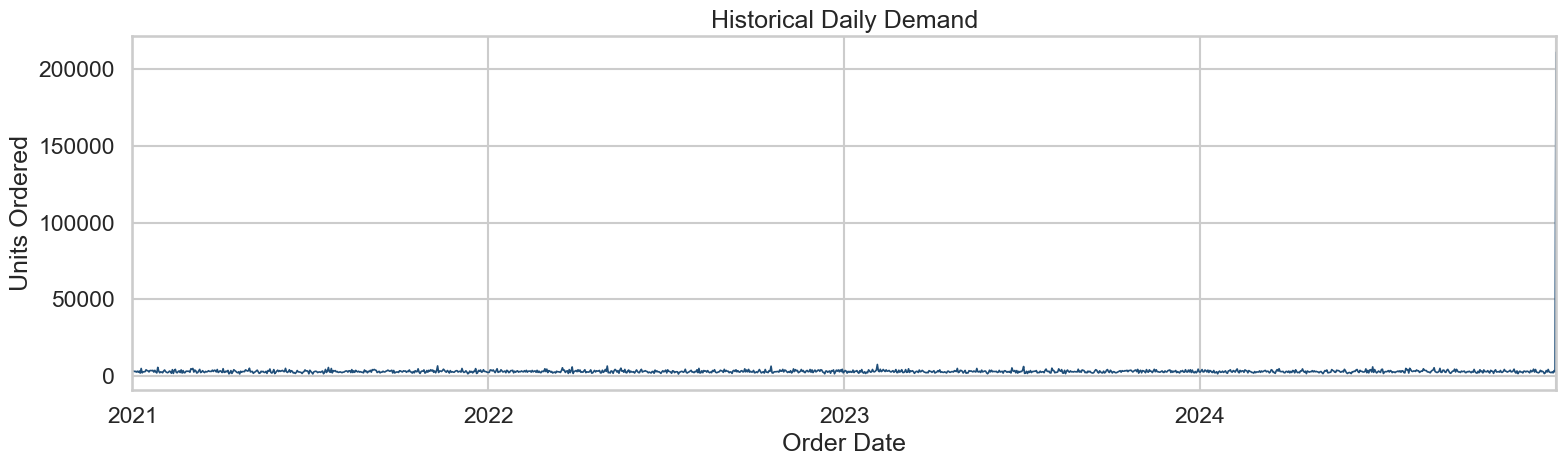

In [4]:
fig, ax = plt.subplots(figsize=(16, 5))
demand_series.plot(ax=ax, color="#1f4e79", linewidth=1.2)
ax.set_title("Historical Daily Demand")
ax.set_xlabel("Order Date")
ax.set_ylabel("Units Ordered")
fig.tight_layout()

## 3. Seasonality validation

SARIMA needs a clear seasonal structure. We validate that structure with an STL decomposition using a weekly seasonal period (`7`) because demand is daily and weekday effects are materially visible in the data.


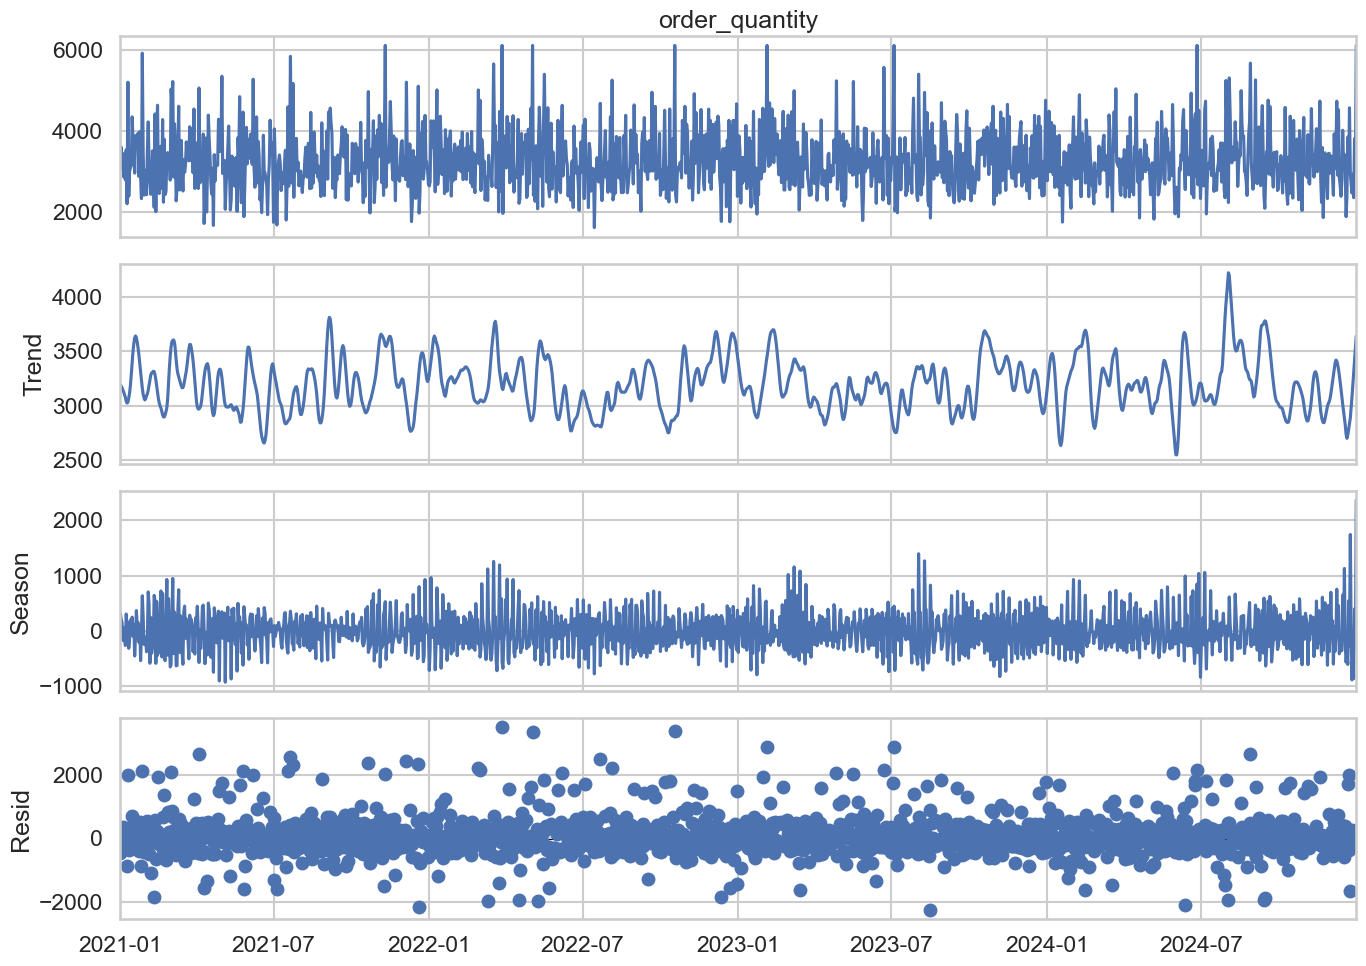

In [5]:
capped_series = demand_series.clip(upper=demand_series.quantile(0.995))
stl_result = STL(capped_series, period=7, robust=True).fit()
fig = stl_result.plot()
fig.set_size_inches(14, 10)
fig.tight_layout()

## 4. Train/test split

The final **90 days** are reserved as the holdout window so we can judge the model on unseen demand from **2024-10-03 through 2024-12-31**.


In [6]:
split_summary = pd.DataFrame(
    [
        {
            "train_start": train_series.index.min().date(),
            "train_end": train_series.index.max().date(),
            "test_start": test_series.index.min().date(),
            "test_end": test_series.index.max().date(),
            "test_days": len(test_series),
        }
    ]
)
split_summary

,train_start,train_end,test_start,test_end,test_days
0,2021-01-01,2024-10-02,2024-10-03,2024-12-31,90


## 5. Baseline model development

The selected SARIMA baseline is:
- Non-seasonal order: `(1, 1, 1)`
- Seasonal order: `(1, 0, 1, 7)`

This is a pragmatic baseline rather than an exhaustively optimized model. The goal is to establish a reproducible benchmark for later sprints.


In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
sarima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                    order_quantity   No. Observations:                 1371
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood              -10939.155
Date:                           Mon, 06 Jul 2026   AIC                          21888.309
Time:                                   21:20:49   BIC                          21914.389
Sample:                               01-01-2021   HQIC                         21898.072
                                    - 10-02-2024                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0195      0.028     -0.695      0.487      -0.074       0.036
ma.L1         -1.0000      0.027    -37.257      0.000      -1.053      -0.947
ar.S.L7       -0.3813      0.513     -0.744      0.457      -1.386       0.623
ma.S.L7        0.4131      0.505      0.818      0.414      -0.577       1.403
sigma2      5.586e+05   4.97e-08   1.12e+13      0.000    5.59e+05    5.59e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               468.38
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.90   Skew:                             0.92
Prob(H) (two-sided):                  0.25   Kurtosis:                         5.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.75e+30. Standard errors may be unstable.
"""

In [8]:
sarima_forecast = sarima_fit.get_forecast(steps=len(test_series))
sarima_frame = sarima_forecast.summary_frame()
sarima_pred = pd.Series(sarima_frame["mean"].values, index=test_series.index, name="sarima_prediction")
sarima_eval = evaluate_forecast(test_series, sarima_pred, "SARIMA")
sarima_eval

,model,mae,rmse,mape
0,SARIMA,"2,831.612","21,849.373",19.012


## 6. Forecast visualization and residual review

The next plots show whether the baseline tracks direction, how wide the confidence interval is, and whether residuals are centered around zero.


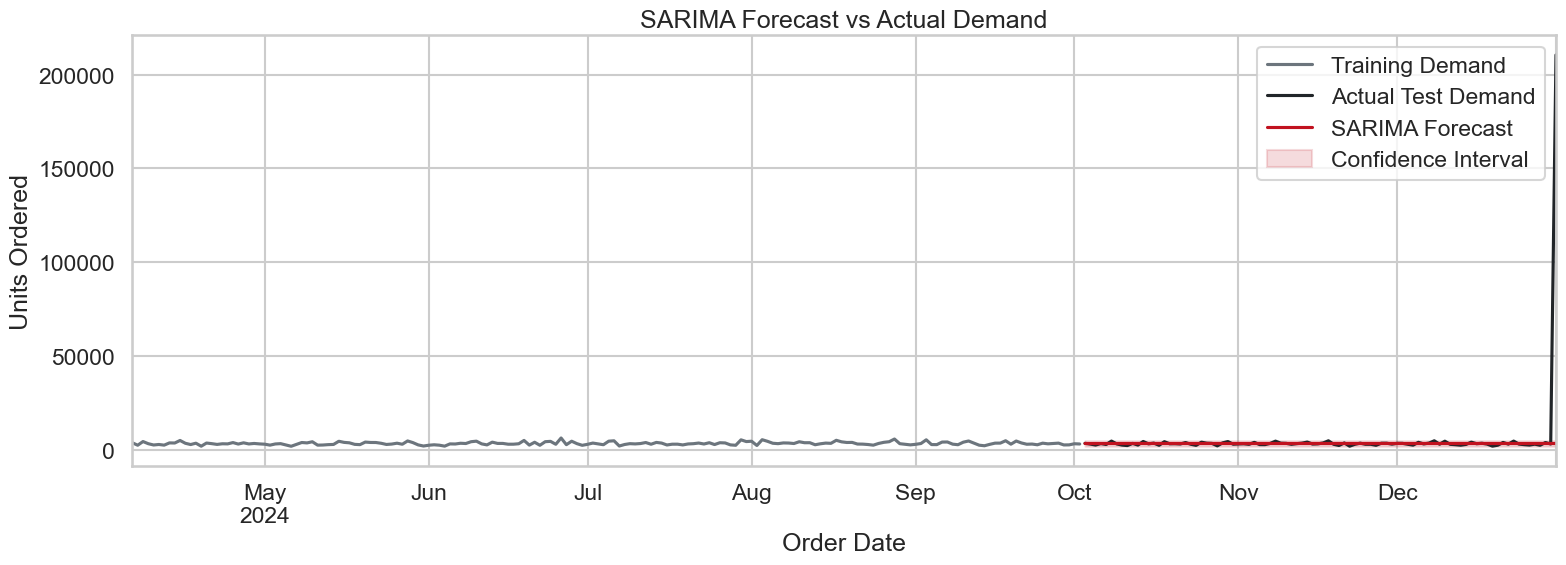

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))
train_series.tail(180).plot(ax=ax, label="Training Demand", color="#6c757d")
test_series.plot(ax=ax, label="Actual Test Demand", color="#212529")
sarima_pred.plot(ax=ax, label="SARIMA Forecast", color="#c1121f")
ax.fill_between(
    test_series.index,
    sarima_frame["mean_ci_lower"].values,
    sarima_frame["mean_ci_upper"].values,
    color="#c1121f",
    alpha=0.15,
    label="Confidence Interval",
)
ax.set_title("SARIMA Forecast vs Actual Demand")
ax.set_xlabel("Order Date")
ax.set_ylabel("Units Ordered")
ax.legend()
fig.tight_layout()

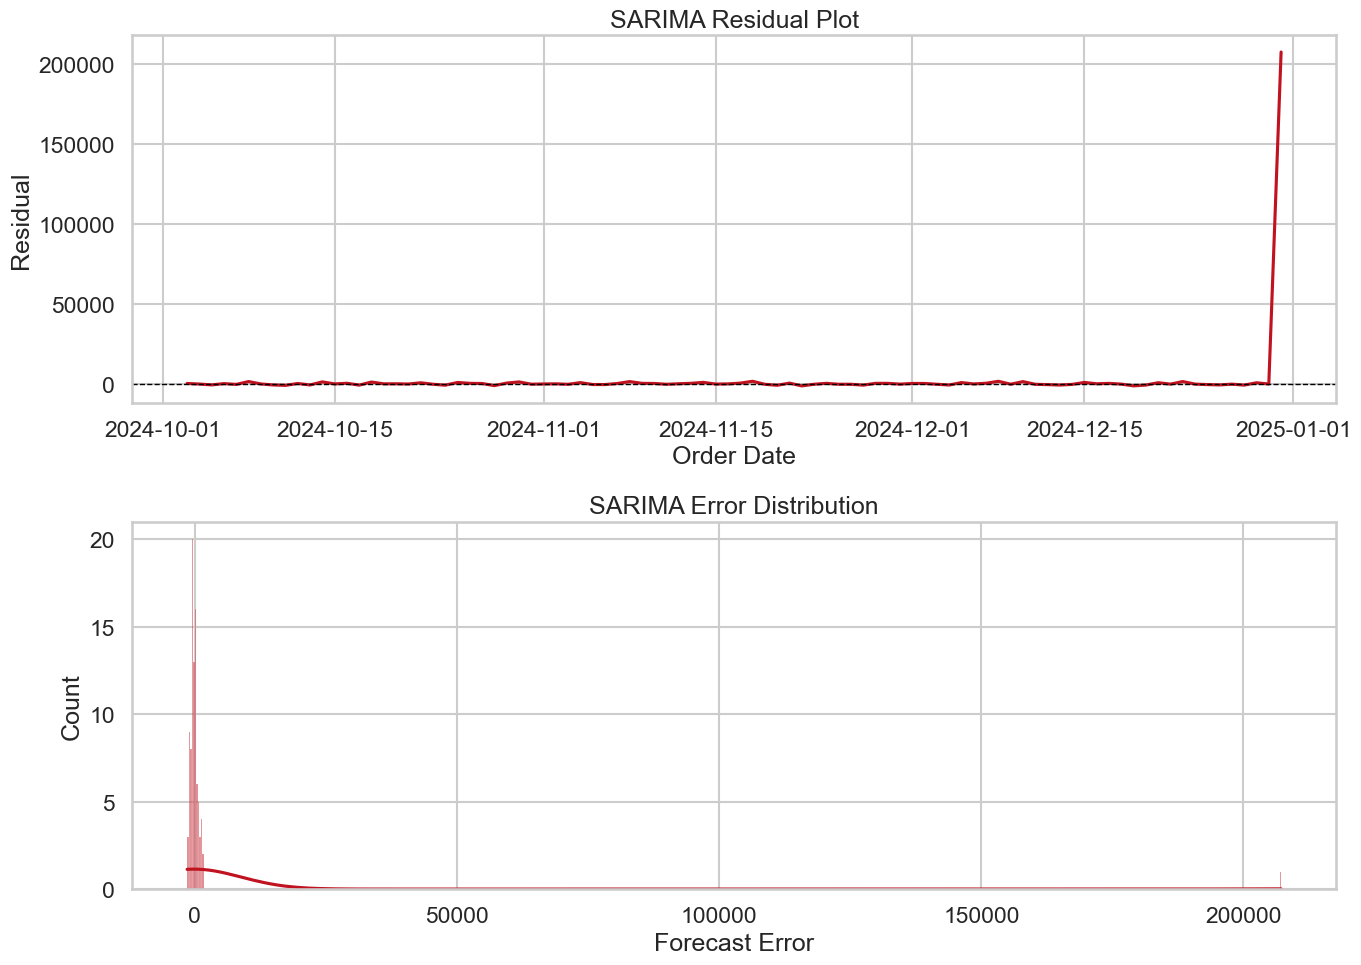

In [10]:
sarima_residuals = test_series - sarima_pred

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes[0].plot(test_series.index, sarima_residuals, color="#c1121f")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("SARIMA Residual Plot")
axes[0].set_xlabel("Order Date")
axes[0].set_ylabel("Residual")

sns.histplot(sarima_residuals, kde=True, ax=axes[1], color="#c1121f")
axes[1].set_title("SARIMA Error Distribution")
axes[1].set_xlabel("Forecast Error")
fig.tight_layout()

## 7. Future demand forecast

For planning purposes, the forward 30-day forecast is refit on a capped version of the full history so that the single extreme spike on **2024-12-31** does not dominate January projections.


In [11]:
future_model = SARIMAX(
    capped_series,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
future_fit = future_model.fit(disp=False)
future_forecast = future_fit.get_forecast(steps=FORECAST_HORIZON).summary_frame().reset_index()
future_forecast = future_forecast.rename(
    columns={
        "index": "date",
        "mean": "forecast_demand",
        "mean_ci_lower": "lower_ci",
        "mean_ci_upper": "upper_ci",
    }
)
future_forecast.head(10)

order_quantity,date,forecast_demand,mean_se,lower_ci,upper_ci
0,2025-01-01,"3,188.059",732.933,"1,751.537","4,624.582"
1,2025-01-02,"3,266.028",733.157,"1,829.066","4,702.990"
2,2025-01-03,"3,273.544",733.158,"1,836.581","4,710.507"
3,2025-01-04,"3,232.928",733.158,"1,795.965","4,669.891"
4,2025-01-05,"3,298.281",733.158,"1,861.318","4,735.244"
5,2025-01-06,"3,249.610",733.158,"1,812.647","4,686.572"
6,2025-01-07,"3,368.801",733.158,"1,931.838","4,805.763"
7,2025-01-08,"3,280.126",733.556,"1,842.382","4,717.870"
8,2025-01-09,"3,280.868",733.556,"1,843.125","4,718.612"
9,2025-01-10,"3,276.766",733.556,"1,839.022","4,714.509"


## 8. MLflow logging

This step records the baseline configuration and evaluation metrics so future iterations can be compared cleanly.


In [12]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("module5_demand_forecasting")

with mlflow.start_run(run_name="sarima_baseline_notebook"):
    mlflow.log_param("data_path", str(DATA_PATH.relative_to(PROJECT_ROOT)))
    mlflow.log_param("order", (1, 1, 1))
    mlflow.log_param("seasonal_order", (1, 0, 1, 7))
    for metric_name, metric_value in sarima_eval.iloc[0].items():
        if metric_name != "model":
            mlflow.log_metric(metric_name, float(metric_value))

## 9. Business interpretation

- SARIMA is a strong baseline because it captures recurring weekly patterns with transparent assumptions.
- The largest error concentration comes from the unusual demand spike on **2024-12-31**, which should be reviewed as a potential one-off business event.
- This model is suitable as an aggregate planning benchmark for procurement teams, but not yet for SKU-level forecasting because product histories are too sparse at the daily level.

The comparison report in `Reports/module5_demand_forecasting/forecast_comparison_report.md` determines whether SARIMA or Prophet should be promoted as the project baseline.
